In [1]:
import pygmt
import pandas as pd
import h5py
import numpy as np
import xarray as xr

In [2]:
with h5py.File('OUTPUT_FILES/initial_model.h5', 'r') as f:
    initial_vs = f['vs'][:]
    initial_zeta = f['zeta'][:]
with h5py.File('OUTPUT_FILES/final_model.h5', 'r') as f:
    x = f['x'][:]
    y = f['y'][:]
    z = f['z'][:]
    final_vs = f['vsv'][:]
    final_zeta = f['zeta'][:]
with h5py.File('OUTPUT_FILES/target_model.h5', 'r') as f:
    target_vs = f['vs'][:]
dv = (final_vs - initial_vs) / initial_vs * 100
dvt = (target_vs - initial_vs) / initial_vs * 100
dzeta = (final_zeta - initial_zeta) / initial_zeta * 100

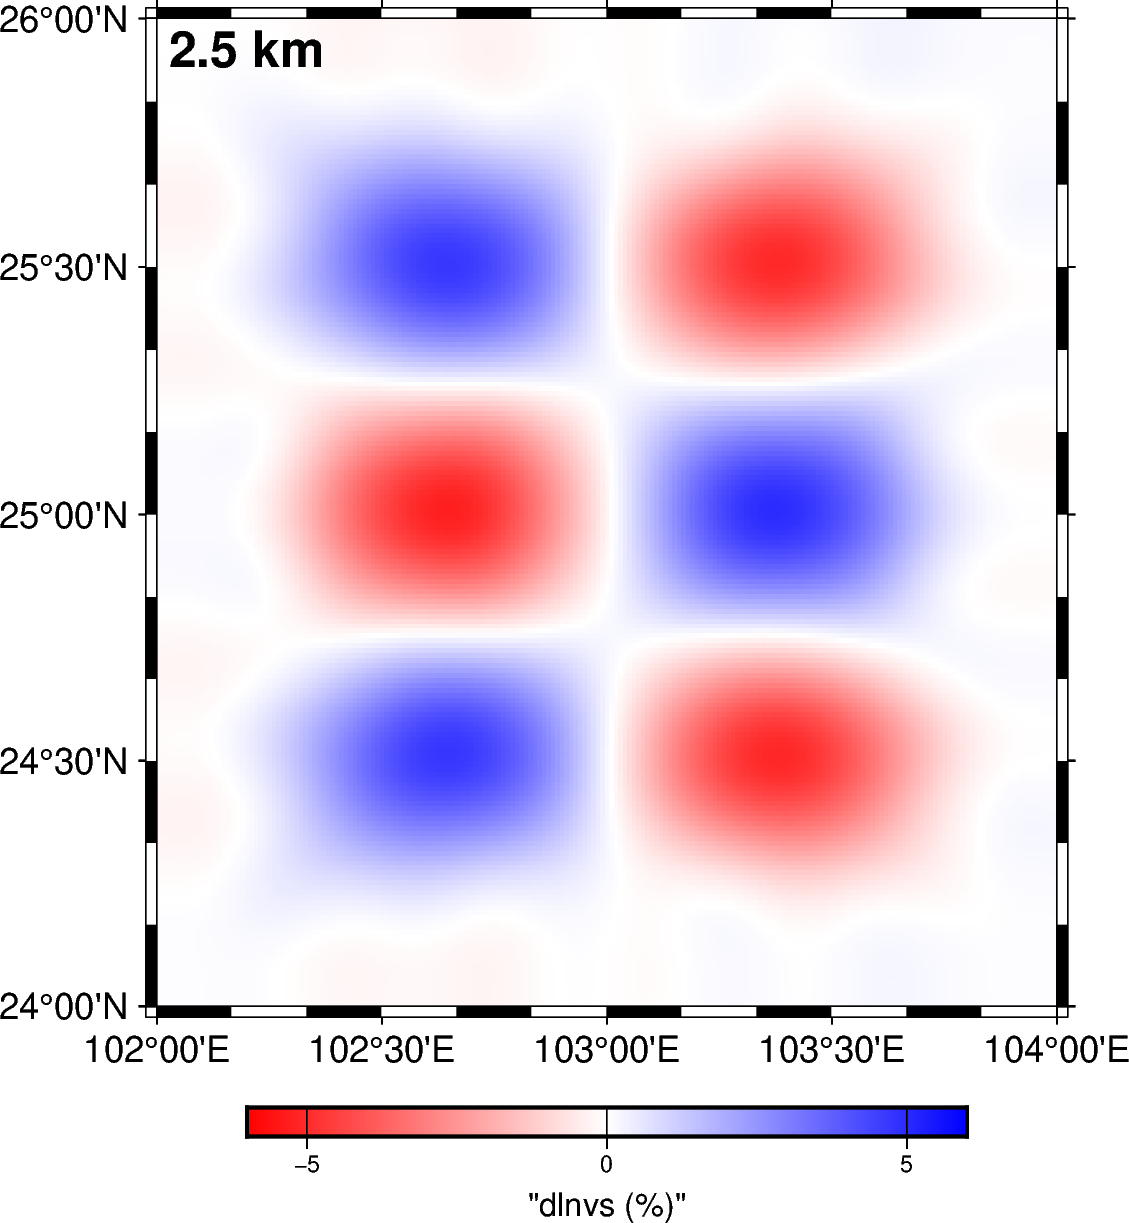

In [3]:
idep = 5
region = [102, 104, 24,26]
xx, yy = np.meshgrid(x, y, indexing='ij')
grid = pygmt.surface(x=xx.ravel(), y=yy.ravel(), z=dzeta[:, :, idep].ravel(), region=region, spacing='0.01/0.01')
fig = pygmt.Figure()
pygmt.makecpt(cmap='polar', series=[-6, 6, 0.01], background=True, continuous=True, reverse=True)
fig.grdimage(
    grid,
    cmap=True,
    region=region,
    projection='M3i',
    frame='af'
)
fig.text(text=f"{z[idep]} km", position='TL', font='12p,Helvetica-Bold', offset='0.1/-0.1')
fig.colorbar(frame='xag+l"dlnvs (%)"')
fig.show()

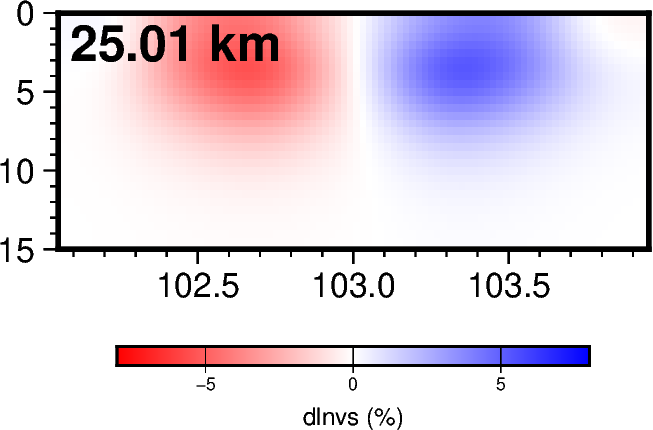

In [4]:
def to_xarray(data, x, y, key="z"):
    """Convert a 2-D NumPy array to an xarray.DataArray indexed on (lat, lon)."""
    return xr.DataArray(data.T, coords=[y, x], dims=["lat", "lon"], name=key)

iy = len(y) // 2
ds = to_xarray(dzeta[:, iy, :], x, z)

fig = pygmt.Figure()
pygmt.makecpt(cmap='polar', series=[-8, 8, 0.1], background=True, continuous=True, reverse=True)
fig.grdimage(
    ds,
    cmap=True,
    region=[x.min(), x.max(), z.min(), z.max()],
    projection='X5c/-2c',
    frame='af'
)
fig.text(text=f"{y[iy]} km", position='TL', font='12p,Helvetica-Bold', offset='0.1/-0.1')
fig.colorbar(frame='xag+ldlnvs (%)')
fig.show()